# Synthetic Health Data Framework for Pregnancy-Related Diabetes & Hypertension

**BMC Medical Informatics and Decision Making — Synthetic Health Data Collection**

This notebook implements a holistic framework with:
1. **Data loading & cleaning** from your Excel file
2. **Synthetic data generation** with 3 generators (GaussianCopula, CTGAN, TVAE)
3. **FIDELITY** evaluation (Kolmogorov–Smirnov, correlation distance)
4. **UTILITY** evaluation (TRTR / TSTR / TRTS)
5. **PRIVACY** evaluation (DCR + Membership Inference Attack)
6. **PHENOTYPE PRESERVATION** (Latent Class Analysis via GMM, SHAP)
7. **Eight publication-ready figures** at 1200 dpi

> Run the cells **in order** the first time. After everything is computed, you can re-run any individual analysis or figure cell.


In [1]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.0 MB/s eta 0:00:00


## 0. Setup

Run this cell once. If a package is missing, uncomment the `pip install` line.


In [2]:
# !pip install sdv shap pandas numpy matplotlib seaborn scikit-learn scipy openpyxl

import warnings
warnings.filterwarnings("ignore")

import time, pickle, os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from scipy import stats
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

from sdv.single_table import CTGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

import shap
# ─── Configuration ──────────────────────────────────────────────────────
EXCEL_PATH   = Path("/content/data.xlsx")   # single source of truth
SHEET_NAME   = "Combined DATA"
OUTPUT_DIR   = Path("./outputs")
FIG_DIR      = OUTPUT_DIR / "figures"

N_SYNTHETIC  = 2000
EPOCHS_DL    = 200          # 300–500 recommended for final submission
BATCH_SIZE   = 50
RANDOM_STATE = 42
TARGET_COL   = "Group"

# ─── Create output directories ──────────────────────────────────────────
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ─── Load data ──────────────────────────────────────────────────────────
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)

# Publication style
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size":       10,
    "axes.labelsize":  11,
    "axes.titlesize":  12,
    "savefig.dpi":     1200,
    "savefig.bbox":    "tight",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

GEN_COLORS = {
    "Real":           "#2C3E50",
    "GaussianCopula": "#3498DB",
    "CTGAN":          "#E74C3C",
    "TVAE":           "#27AE60",
}
GEN_ORDER = ["GaussianCopula", "CTGAN", "TVAE"]
GROUP_LABELS = {1: "Control", 2: "GDM", 3: "PGDM", 4: "GestHTN", 5: "PreGestHTN"}

print("✓ Setup complete")


✓ Setup complete


## 1. Load & Clean Excel Data

Reads your Excel file, standardizes column names, drops identifiers, fills missing values.


In [3]:
COLUMN_MAP = {
    "HASTA ADI SOYADI":                            "PatientName",
    "PROT NO":                                     "ProtocolNo",
    "Groups":                                      "Group",
    "AGE":                                         "Age",
    "GRAVIDITY":                                   "Gravidity",
    "PARITY":                                      "Parity",
    "MISCARRIGE":                                  "Miscarriage",
    "ETHNICITY":                                   "Ethnicity",
    "SOCIOECONOMIC STATUS":                        "SocioEcon",
    "WEIGHT":                                      "Weight",
    "HEIGHT":                                      "Height",
    "BMI":                                         "BMI",
    "GESTASIONAL WEIGHT GAIN":                     "WeightGain",
    "HISTORY OF OBSTETRIC DISORDER":               "ObstHistory",
    "FAMILY HISTORY OF DIABETES":                  "FamDiabetes",
    "MEDICAL DISEASES":                            "MedDiseases",
    "HISTORY OF PRETERM LABOUR":                   "PretermHx",
    "SMOKER":                                      "Smoker",
    "CONCEPTION":                                  "Conception",
    "GESTASIONAL AGE AT DIAGNOSIS":                "GA_Diagnosis",
    "POLYHIYDROAMNIOSIS":                          "Polyhydramnios",
    "DEEPEST VERTICAL AF":                         "AF_Depth",
    "IUGR":                                        "IUGR",
    "ABNORMAL DOPPLER US":                         "DopplerUS",
    "CERVİCAL LENGHT":                             "CervicalLength",
    "MODE OF DELIVERY":                            "DeliveryMode",
    "GESTASIONAL AGE AT DELIVERY":                 "GA_Delivery",
    "FETAL SEX":                                   "FetalSex",
    "BIRTH WEIGHT":                                "BirthWeight",
    "AGGAR 1. MİN":                                "Apgar1",
    "AGGAR 5. MİN":                                "Apgar5",
    "CORD BLOOD PH":                               "Cord_pH",
    "NICU ADM":                                    "NICU",
    "PHARMACOLOCICAL TREATMENT":                   "PharmTreat",
    "PROTEIN IN URINE":                            "UrineProtein",
    "SPOT URINE PROT/CR":                          "SpotProtCr",
    "24-HOUR URİNE COLLECTİON FOR TOTAL PROTEİN":  "Urine24hProt",
    "WBC": "WBC", "RBC": "RBC", "HGB": "Hgb", "HCT": "Hct",
    "PLT": "Plt", "NEU": "Neu", "LYM": "Lym",
    "FASTİNG PLASMA GLYCOSE": "FastingGlu",
    "1 H PLASMA GLUCOSE":     "Glu1h",
    "2 H PLASMA GLUCOSE":     "Glu2h",
    "HEMA1C":                 "HbA1c",
    "CREATININE":             "Creatinine",
    "AST": "AST", "ALT": "ALT", "LDH": "LDH",
    "TRGLYSERİDE":            "Triglyceride",
    "HDL CHOLESTEROL":        "HDL",
    "LDL CHOLESTEROL":        "LDL",
}
DROP_COLS = ["PatientName", "ProtocolNo", "Unnamed: 55", "Unnamed: 56","Unnamed: 57"]

real_df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
real_df.columns = real_df.columns.str.strip()
real_df = real_df.rename(columns=COLUMN_MAP)

unmapped = [c for c in real_df.columns if c not in COLUMN_MAP.values()]
if unmapped:
    print("! Unmapped columns:", unmapped)

for c in DROP_COLS:
    if c in real_df.columns:
        real_df = real_df.drop(columns=c)

# Impute missing
for c in real_df.columns:
    if real_df[c].dtype in [np.float64, np.int64]:
        if real_df[c].isna().any():
            real_df[c] = real_df[c].fillna(real_df[c].median())
    else:
        if real_df[c].isna().any():
            mode_val = real_df[c].mode()
            real_df[c] = real_df[c].fillna(mode_val.iloc[0] if not mode_val.empty else 0)

if "Group" in real_df.columns:
    real_df["Group"] = real_df["Group"].astype(int)

print(f"Final shape: {real_df.shape}")
print(f"Group distribution: {real_df['Group'].value_counts().sort_index().to_dict()}")
real_df.head()


! Unmapped columns: ['Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57']
Final shape: (236, 53)
Group distribution: {1: 97, 2: 56, 3: 34, 4: 28, 5: 21}


,Group,Age,Gravidity,Parity,Miscarriage,Ethnicity,SocioEcon,Weight,Height,BMI,...,Glu1h,Glu2h,HbA1c,Creatinine,AST,ALT,LDH,Triglyceride,HDL,LDL
0,1,28.0,4.0,1.0,2.0,1.0,5.0,67.0,165.0,32.5,...,175.5,147.0,5.0,0.43,19.0,16.0,363.0,106.0,84.0,112.0
1,1,32.0,2.0,1.0,0.0,1.0,1.0,74.0,148.0,32.5,...,175.5,147.0,5.7,0.40,14.0,7.0,236.0,233.0,53.0,74.0
2,1,36.0,7.0,5.0,1.0,2.0,1.0,61.0,158.0,32.5,...,175.5,147.0,5.4,0.53,14.0,9.0,283.0,188.0,73.0,194.0
3,1,28.0,6.0,2.0,3.0,2.0,1.0,65.0,160.0,32.5,...,175.5,147.0,5.2,0.38,14.0,9.0,259.0,206.0,66.0,78.0
4,1,38.0,3.0,1.0,1.0,1.0,2.0,76.0,164.0,32.5,...,175.5,147.0,5.2,0.58,17.0,17.0,311.0,259.0,44.0,137.0


In [4]:
real_df["GA_Delivery"] = real_df["GA_Delivery"].astype(str).str.extract(r"(\d+)").astype(float)
real_df["BirthWeight"] = real_df["BirthWeight"].astype(str).str.split("/").str[0]
real_df["RBC"] = real_df["RBC"].astype(str).str.split(";").str[0]
real_df = real_df[real_df['Cord_pH'] != 'DIŞ MERKEZ']

In [5]:
real_df = real_df.apply(lambda col: col.astype(str).str.split('/').str[0])
real_df = real_df.apply(pd.to_numeric, errors='coerce')

## 2. Train / Holdout Split

The holdout set is reserved for the Membership Inference Attack later.


In [6]:
real_train, real_holdout = train_test_split(
    real_df, test_size=0.25, stratify=real_df["Group"], random_state=RANDOM_STATE
)
print(f"Train (used to fit generators): {real_train.shape}")
print(f"Holdout (for MIA):              {real_holdout.shape}")

real_df.to_csv(OUTPUT_DIR / "real_data.csv", index=False)
real_train.to_csv(OUTPUT_DIR / "real_train.csv", index=False)
real_holdout.to_csv(OUTPUT_DIR / "real_holdout.csv", index=False)

num_cols = [c for c in real_df.columns
            if real_df[c].dtype in [np.float64, np.int64] and c != TARGET_COL]
print(f"Numeric columns for analyses: {len(num_cols)}")


Train (used to fit generators): (174, 53)
Holdout (for MIA):              (59, 53)
Numeric columns for analyses: 52


## 3. Build SDV Metadata


In [7]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_train)
for c in real_train.columns:
    if real_train[c].nunique() <= 10:
        metadata.update_column(column_name=c, sdtype="categorical")

print("Metadata ready.")
print({c: metadata.columns[c]["sdtype"] for c in list(metadata.columns)[:10]})


Metadata ready.
{'Group': 'categorical', 'Age': 'numerical', 'Gravidity': 'categorical', 'Parity': 'categorical', 'Miscarriage': 'categorical', 'Ethnicity': 'categorical', 'SocioEcon': 'categorical', 'Weight': 'numerical', 'Height': 'numerical', 'BMI': 'numerical'}


## 4. Generate Synthetic Data — 3 Generators

This is the slowest step. Total ~3–5 minutes with `EPOCHS_DL=200`.


In [8]:
synthetics = {}

# --- GaussianCopula (fast baseline)
print("[1/3] Fitting GaussianCopula..."); t = time.time()
gc = GaussianCopulaSynthesizer(metadata)
gc.fit(real_train)
synthetics["GaussianCopula"] = gc.sample(num_rows=N_SYNTHETIC)
print(f"      Done in {time.time() - t:.1f}s")

# --- CTGAN
print(f"[2/3] Fitting CTGAN (epochs={EPOCHS_DL})..."); t = time.time()
ctgan = CTGANSynthesizer(metadata, epochs=EPOCHS_DL, batch_size=BATCH_SIZE, verbose=False)
ctgan.fit(real_train)
synthetics["CTGAN"] = ctgan.sample(num_rows=N_SYNTHETIC)
print(f"      Done in {time.time() - t:.1f}s")

# --- TVAE
print(f"[3/3] Fitting TVAE (epochs={EPOCHS_DL})..."); t = time.time()
tvae = TVAESynthesizer(metadata, epochs=EPOCHS_DL, batch_size=BATCH_SIZE)
tvae.fit(real_train)
synthetics["TVAE"] = tvae.sample(num_rows=N_SYNTHETIC)
print(f"      Done in {time.time() - t:.1f}s")

# Save
for name, df in synthetics.items():
    df.to_csv(OUTPUT_DIR / f"synth_{name}.csv", index=False)

print("\n✓ All synthetic datasets saved to", OUTPUT_DIR)


[1/3] Fitting GaussianCopula...
      Done in 4.2s
[2/3] Fitting CTGAN (epochs=200)...
      Done in 67.9s
[3/3] Fitting TVAE (epochs=200)...
      Done in 22.4s

✓ All synthetic datasets saved to outputs


## 5. FIDELITY Evaluation

- **Kolmogorov–Smirnov test** on every numeric variable
- **Correlation matrix L1 distance** between real and synthetic

Lower values = better fidelity.


In [9]:
def compute_fidelity(real_df, synth_df, num_cols):
    ks_stats = {}
    for c in num_cols:
        stat, p = stats.ks_2samp(real_df[c].dropna(), synth_df[c].dropna())
        ks_stats[c] = {"KS_stat": stat, "p_value": p}
    corr_real  = real_df[num_cols].corr().fillna(0).values
    corr_synth = synth_df[num_cols].corr().fillna(0).values
    return {
        "ks_stats":       ks_stats,
        "mean_KS":        np.mean([v["KS_stat"] for v in ks_stats.values()]),
        "median_KS":      np.median([v["KS_stat"] for v in ks_stats.values()]),
        "corr_diff_mean": np.abs(corr_real - corr_synth).mean(),
    }

fidelity_results = {n: compute_fidelity(real_train, s, num_cols)
                    for n, s in synthetics.items()}

pd.DataFrame({
    name: {"mean_KS":   r["mean_KS"],
           "median_KS": r["median_KS"],
           "corr_Δ":    r["corr_diff_mean"]}
    for name, r in fidelity_results.items()
}).round(3)


,GaussianCopula,CTGAN,TVAE
mean_KS,0.137,0.281,0.160
median_KS,0.077,0.242,0.147
corr_Δ,0.063,0.096,0.077


## 6. UTILITY Evaluation (TRTR / TSTR / TRTS)

- **TRTR** (Train Real, Test Real) = baseline
- **TSTR** (Train Synthetic, Test Real) = **the key metric** — does synthetic data train models that work on real patients?
- **TRTS** (Train Real, Test Synthetic) = sanity check


In [10]:
def utility_tstr_trts(real_df, synth_df, target=TARGET_COL, test_size=0.3):
    feat_cols = [c for c in real_df.columns if c != target]
    X_real, y_real = real_df[feat_cols], real_df[target]
    X_synth, y_synth = synth_df[feat_cols], synth_df[target]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_real, y_real, test_size=test_size, stratify=y_real, random_state=RANDOM_STATE
    )

    out = {}
    m = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    out["TRTR"] = {"accuracy": accuracy_score(y_te, m.predict(X_te)),
                   "f1":       f1_score(y_te, m.predict(X_te), average="weighted")}

    m2 = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_synth, y_synth)
    out["TSTR"] = {"accuracy": accuracy_score(y_te, m2.predict(X_te)),
                   "f1":       f1_score(y_te, m2.predict(X_te), average="weighted")}

    counts = y_synth.value_counts()
    valid = counts[counts >= 2].index
    mask = y_synth.isin(valid)
    Xs, ys = X_synth[mask], y_synth[mask]
    try:
        _, Xs_te, _, ys_te = train_test_split(
            Xs, ys, test_size=test_size, stratify=ys, random_state=RANDOM_STATE
        )
    except ValueError:
        _, Xs_te, _, ys_te = train_test_split(
            Xs, ys, test_size=test_size, random_state=RANDOM_STATE
        )
    known = set(m.classes_)
    tmask = ys_te.isin(known)
    out["TRTS"] = {"accuracy": accuracy_score(ys_te[tmask], m.predict(Xs_te[tmask])),
                   "f1":       f1_score(ys_te[tmask], m.predict(Xs_te[tmask]), average="weighted")}
    return out

utility_results = {n: utility_tstr_trts(real_df, s) for n, s in synthetics.items()}

util_table = pd.DataFrame({
    name: {"TRTR_acc": r["TRTR"]["accuracy"],
           "TSTR_acc": r["TSTR"]["accuracy"],
           "TRTS_acc": r["TRTS"]["accuracy"],
           "TRTR_f1":  r["TRTR"]["f1"],
           "TSTR_f1":  r["TSTR"]["f1"],
           "TRTS_f1":  r["TRTS"]["f1"]}
    for name, r in utility_results.items()
}).round(3)
util_table


,GaussianCopula,CTGAN,TVAE
TRTR_acc,0.929,0.929,0.929
TSTR_acc,0.471,0.414,0.800
TRTS_acc,0.415,0.318,0.730
TRTR_f1,0.927,0.927,0.927
TSTR_f1,0.367,0.248,0.788
TRTS_f1,0.389,0.275,0.707


## 7. PRIVACY Evaluation

- **DCR** (Distance to Closest Record): higher = better privacy
- **MIA** (Membership Inference Attack): AUC ≈ 0.5 = perfect privacy; AUC → 1.0 = severe leakage
- **Exact matches** = number of synthetic records that perfectly replicate a real one (must be 0)


In [11]:
def privacy_metrics(real_df, synth_df, num_cols):
    scaler = StandardScaler()
    R = scaler.fit_transform(real_df[num_cols].fillna(0))
    S = scaler.transform(synth_df[num_cols].fillna(0))

    dists = cdist(S, R, metric="euclidean")
    dcr_synth = dists.min(axis=1)
    sorted_d = np.sort(dists, axis=1)
    nndr = sorted_d[:, 0] / (sorted_d[:, 1] + 1e-9)

    dists_rr = cdist(R, R, metric="euclidean")
    np.fill_diagonal(dists_rr, np.inf)
    dcr_real = dists_rr.min(axis=1)

    return {
        "dcr_synth":        dcr_synth, "dcr_real": dcr_real, "nndr": nndr,
        "median_dcr_synth": np.median(dcr_synth),
        "median_dcr_real":  np.median(dcr_real),
        "dcr_ratio":        np.median(dcr_synth) / np.median(dcr_real),
        "exact_matches":    int((dcr_synth < 1e-6).sum()),
    }

def membership_inference_attack(real_train, synth_df, real_holdout, num_cols):
    scaler = StandardScaler()
    R = scaler.fit_transform(real_train[num_cols].fillna(0))
    H = scaler.transform(real_holdout[num_cols].fillna(0))
    S = scaler.transform(synth_df[num_cols].fillna(0))
    d_R = cdist(R, S, metric="euclidean").min(axis=1)
    d_H = cdist(H, S, metric="euclidean").min(axis=1)
    y_true = np.concatenate([np.ones(len(d_R)), np.zeros(len(d_H))])
    scores = np.concatenate([-d_R, -d_H])
    try:    auc = roc_auc_score(y_true, scores)
    except: auc = 0.5
    risk = "low" if auc < 0.60 else "medium" if auc < 0.70 else "high"
    return {"MIA_AUC": auc, "risk": risk}

privacy_results = {n: privacy_metrics(real_train, s, num_cols)
                   for n, s in synthetics.items()}
mia_results     = {n: membership_inference_attack(real_train, s, real_holdout, num_cols)
                   for n, s in synthetics.items()}

priv_table = pd.DataFrame({
    name: {"median_DCR":    privacy_results[name]["median_dcr_synth"],
           "DCR_ratio":     privacy_results[name]["dcr_ratio"],
           "exact_matches": privacy_results[name]["exact_matches"],
           "MIA_AUC":       mia_results[name]["MIA_AUC"],
           "risk":          mia_results[name]["risk"]}
    for name in synthetics.keys()
}).T
priv_table.round(3)


,median_DCR,DCR_ratio,exact_matches,MIA_AUC,risk
GaussianCopula,6.370344,1.13966,0,0.594097,low
CTGAN,7.967909,1.425465,0,0.582116,low
TVAE,3.59708,0.643521,0,0.600136,medium


## 8. PHENOTYPE PRESERVATION — Latent Class Analysis

Fit Gaussian Mixture Models with k=2..8 on real and on each synthetic dataset.  
The optimal k (lowest BIC) should match between real and synthetic if the underlying phenotype structure is preserved.


In [15]:
from sklearn.impute import SimpleImputer

def latent_class_analysis(df, num_cols, k_range=(2,8), n_init=5, max_n=500):
    df_use = df if len(df) <= max_n else df.sample(n=max_n, random_state=RANDOM_STATE)

    # ROBUST IMPUTATION — handles all-NaN columns and inf values
    X_raw = df_use[num_cols].copy()
    X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

    # Drop columns that are entirely NaN
    all_nan_cols = X_raw.columns[X_raw.isna().all()].tolist()
    if all_nan_cols:
        print(f"    ! Dropping all-NaN columns: {all_nan_cols}")
        X_raw = X_raw.drop(columns=all_nan_cols)

    # Median imputation, then zero-fill any remaining NaN
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_raw)
    X_imp = np.nan_to_num(X_imp, nan=0.0, posinf=0.0, neginf=0.0)

    X = StandardScaler().fit_transform(X_imp)

    ks, bic, aic = list(range(k_range[0], k_range[1] + 1)), [], []
    for k in ks:
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              n_init=n_init, random_state=RANDOM_STATE, max_iter=100).fit(X)
        bic.append(gmm.bic(X)); aic.append(gmm.aic(X))
    best_k = ks[int(np.argmin(bic))]
    final = GaussianMixture(n_components=best_k, covariance_type="full",
                            n_init=n_init, random_state=RANDOM_STATE, max_iter=100).fit(X)
    return {"ks": ks, "bic": bic, "aic": aic, "best_k": best_k,
            "labels": final.predict(X), "X_std": X, "df": df_use.reset_index(drop=True)}

print("Running LCA on real data...")
lca_real = latent_class_analysis(real_df, num_cols)
print(f"  REAL best k = {lca_real['best_k']}")

lca_synth = {}
for name, synth in synthetics.items():
    print(f"Running LCA on {name}...")
    lca_synth[name] = latent_class_analysis(synth, num_cols)
    print(f"  {name} best k = {lca_synth[name]['best_k']}")

Running LCA on real data...
  REAL best k = 8
Running LCA on GaussianCopula...
  GaussianCopula best k = 2
Running LCA on CTGAN...
  CTGAN best k = 5
Running LCA on TVAE...
  TVAE best k = 5


## 9. Summary Table — paste this into the manuscript as Table 1


In [16]:
summary = []
for name in GEN_ORDER:
    summary.append({
        "Generator":       name,
        "Mean_KS":         round(fidelity_results[name]["mean_KS"], 3),
        "Corr_Δ":          round(fidelity_results[name]["corr_diff_mean"], 3),
        "TRTR_Acc":        round(utility_results[name]["TRTR"]["accuracy"], 3),
        "TSTR_Acc":        round(utility_results[name]["TSTR"]["accuracy"], 3),
        "TRTS_Acc":        round(utility_results[name]["TRTS"]["accuracy"], 3),
        "Median_DCR":      round(privacy_results[name]["median_dcr_synth"], 2),
        "Exact_Matches":   privacy_results[name]["exact_matches"],
        "MIA_AUC":         round(mia_results[name]["MIA_AUC"], 3),
        "Privacy_Risk":    mia_results[name]["risk"],
        "LCA_Best_K":      lca_synth[name]["best_k"],
    })
summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUTPUT_DIR / "summary_table.csv", index=False)

# Also save the entire results bundle for reproducibility
bundle = dict(real_df=real_df, real_train=real_train, real_holdout=real_holdout,
              synthetics=synthetics, num_cols=num_cols,
              fidelity_results=fidelity_results, utility_results=utility_results,
              privacy_results=privacy_results, mia_results=mia_results,
              lca_real=lca_real, lca_synth=lca_synth)
with open(OUTPUT_DIR / "results_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)

summary_df


,Generator,Mean_KS,Corr_Δ,TRTR_Acc,TSTR_Acc,TRTS_Acc,Median_DCR,Exact_Matches,MIA_AUC,Privacy_Risk,LCA_Best_K
0,GaussianCopula,0.137,0.063,0.929,0.471,0.415,6.37,0,0.594,low,2
1,CTGAN,0.281,0.096,0.929,0.414,0.318,7.97,0,0.582,low,5
2,TVAE,0.160,0.077,0.929,0.800,0.730,3.60,0,0.600,medium,5


---
# Figures (8 main + 2 supplementary, all 1200 dpi)

Each figure is saved as both PNG and PDF in `./outputs/figures/`.


### Figure 1 — Workflow Overview

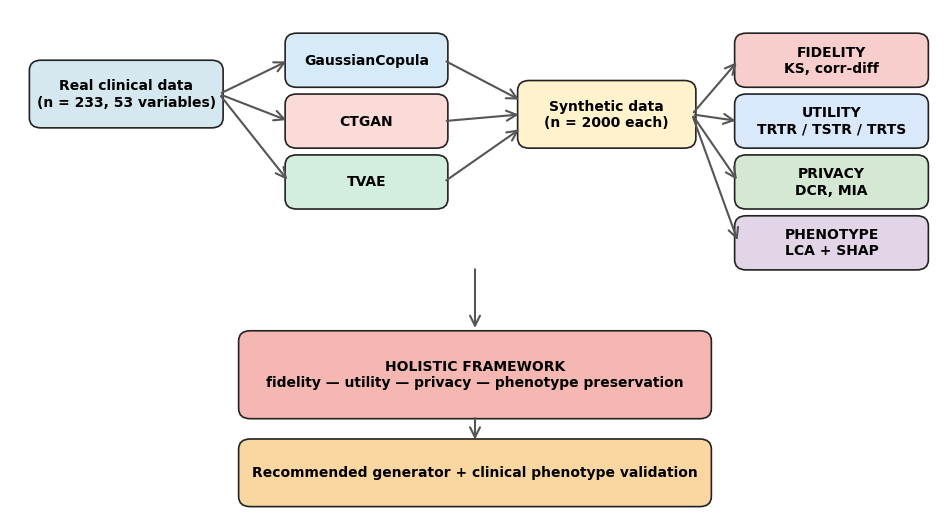

In [17]:
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 7.4); ax.axis("off")

def box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle="round,pad=0.05,rounding_size=0.15",
                                facecolor=color, edgecolor="#222", linewidth=1.2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=10, fontweight="bold")

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
                                 arrowstyle="->", mutation_scale=18,
                                 color="#555", linewidth=1.5))

box(0.3, 5.7, 2.4, 0.9, f"Real clinical data\n(n = {len(real_df)}, {real_df.shape[1]} variables)", "#D5E8F0")
box(3.6, 6.3, 2.0, 0.7, "GaussianCopula", GEN_COLORS["GaussianCopula"] + "33")
box(3.6, 5.4, 2.0, 0.7, "CTGAN",          GEN_COLORS["CTGAN"] + "33")
box(3.6, 4.5, 2.0, 0.7, "TVAE",           GEN_COLORS["TVAE"] + "33")
box(6.6, 5.4, 2.2, 0.9, f"Synthetic data\n(n = {N_SYNTHETIC} each)", "#FFF2CC")
box(9.4, 6.3, 2.4, 0.7, "FIDELITY\nKS, corr-diff",     "#F8CECC")
box(9.4, 5.4, 2.4, 0.7, "UTILITY\nTRTR / TSTR / TRTS", "#DAE8FC")
box(9.4, 4.5, 2.4, 0.7, "PRIVACY\nDCR, MIA",            "#D5E8D4")
box(9.4, 3.6, 2.4, 0.7, "PHENOTYPE\nLCA + SHAP",        "#E1D5E7")
box(3.0, 1.4, 6.0, 1.2, "HOLISTIC FRAMEWORK\nfidelity — utility — privacy — phenotype preservation", "#F5B7B1")
box(3.0, 0.1, 6.0, 0.9, "Recommended generator + clinical phenotype validation", "#FAD7A0")

arrow(2.7, 6.15, 3.6, 6.65); arrow(2.7, 6.15, 3.6, 5.75); arrow(2.7, 6.15, 3.6, 4.85)
arrow(5.6, 6.65, 6.6, 6.05); arrow(5.6, 5.75, 6.6, 5.85); arrow(5.6, 4.85, 6.6, 5.65)
for y in [6.65, 5.75, 4.85, 3.95]: arrow(8.8, 5.85, 9.4, y)
arrow(6.0, 3.6, 6.0, 2.65); arrow(6.0, 1.4, 6.0, 1.0)

#ax.set_title("Figure 1. Overall workflow of the synthetic data framework",
            # fontsize=13, fontweight="bold", pad=12)
plt.savefig(FIG_DIR / "Figure1_workflow.png", dpi=700, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure1_workflow.pdf", bbox_inches="tight")
plt.show()


### Figure 2 — Fidelity (correlation heatmaps + KS bar chart)

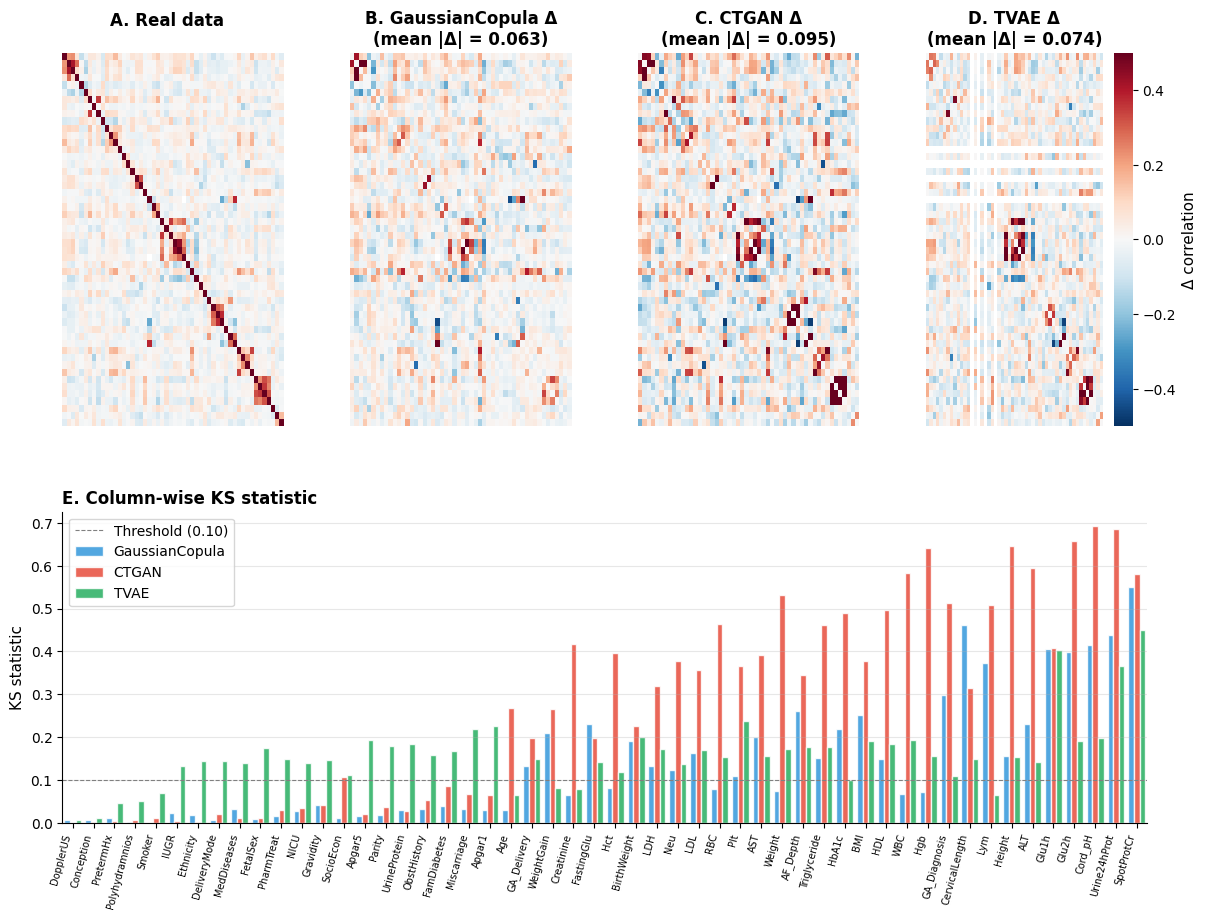

In [ ]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 4, height_ratios=[1.2, 1], hspace=0.25, wspace=0.3)

corr_real = real_train[num_cols].corr()

ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(corr_real, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            cbar=False, xticklabels=False, yticklabels=False, ax=ax0)
ax0.set_title("A. Real data  ", fontweight="bold", y=1.05)

for i, name in enumerate(GEN_ORDER):
    ax = fig.add_subplot(gs[0, i + 1])
    diff = corr_real - synthetics[name][num_cols].corr()
    sns.heatmap(diff, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
                cbar=(i == 2), xticklabels=False, yticklabels=False, ax=ax,
                cbar_kws={"label": "Δ correlation"} if i == 2 else {})
    mad = fidelity_results[name]["corr_diff_mean"]
    ax.set_title(f"{'BCD'[i]}. {name} Δ\n(mean |Δ| = {mad:.3f})", fontweight="bold")

ax_ks = fig.add_subplot(gs[1, :])
ks_data = [{"Generator": n, "Variable": v, "KS": s["KS_stat"]}
           for n in GEN_ORDER for v, s in fidelity_results[n]["ks_stats"].items()]
ks_df = pd.DataFrame(ks_data)
vars_sorted = ks_df.groupby("Variable")["KS"].mean().sort_values().index.tolist()
ks_pivot = ks_df.pivot(index="Variable", columns="Generator", values="KS").loc[vars_sorted]

x, w = np.arange(len(vars_sorted)), 0.27
for i, name in enumerate(GEN_ORDER):
    ax_ks.bar(x + (i - 1)*w, ks_pivot[name].values, w,
              label=name, color=GEN_COLORS[name], alpha=0.85, edgecolor="white")
ax_ks.set_xticks(x); ax_ks.set_xticklabels(vars_sorted, rotation=75, ha="right", fontsize=7)
ax_ks.set_ylabel("KS statistic")
ax_ks.set_title("E. Column-wise KS statistic", fontweight="bold", loc="left") #(lower = better)
ax_ks.axhline(0.1, color="grey", linestyle="--", linewidth=0.8, label="Threshold (0.10)")
ax_ks.legend(loc="upper left"); ax_ks.grid(axis="y", alpha=0.3)
ax_ks.margins(x=0)
ax_ks.set_xlim(-0.5, len(x) - 0.5)
#fig.suptitle("Figure 2. Fidelity evaluation: correlation structure and marginals",
 #            fontsize=13, fontweight="bold", y=0.995)
plt.savefig(FIG_DIR / "Figure2_fidelity.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure2_fidelity.pdf", bbox_inches="tight")
plt.show()


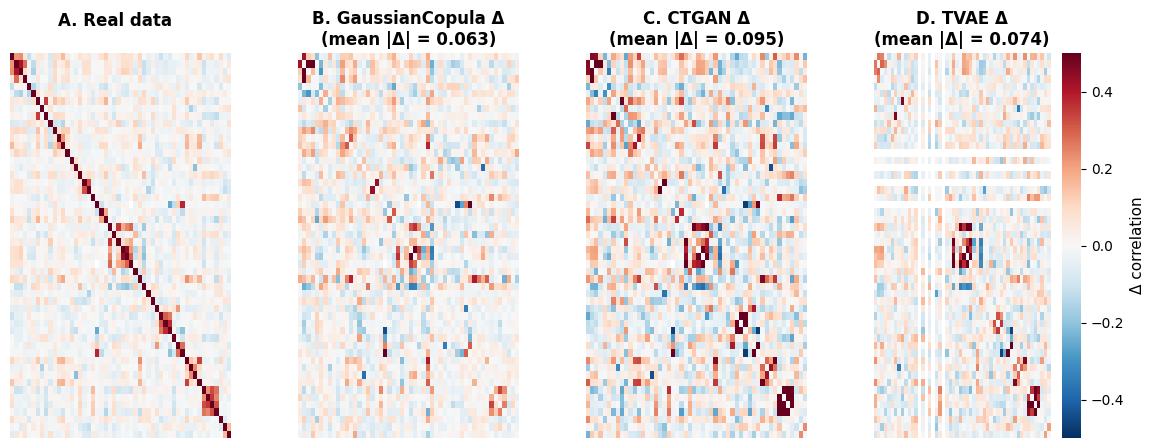

In [ ]:
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 4, wspace=0.3)

corr_real = real_train[num_cols].corr()

# A
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(corr_real, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            cbar=False, xticklabels=False, yticklabels=False, ax=ax0)
ax0.set_title("A. Real data  ", fontweight="bold", y=1.05)

# B–D
for i, name in enumerate(GEN_ORDER):
    ax = fig.add_subplot(gs[0, i + 1])
    diff = corr_real - synthetics[name][num_cols].corr()
    sns.heatmap(diff, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
                cbar=(i == 2), xticklabels=False, yticklabels=False, ax=ax,
                cbar_kws={"label": "Δ correlation"} if i == 2 else {})
    mad = fidelity_results[name]["corr_diff_mean"]
    ax.set_title(f"{'BCD'[i]}. {name} Δ\n(mean |Δ| = {mad:.3f})", fontweight="bold")

plt.savefig(FIG_DIR / "Figure2_correlation.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure2_correlation.pdf", bbox_inches="tight")
plt.show()

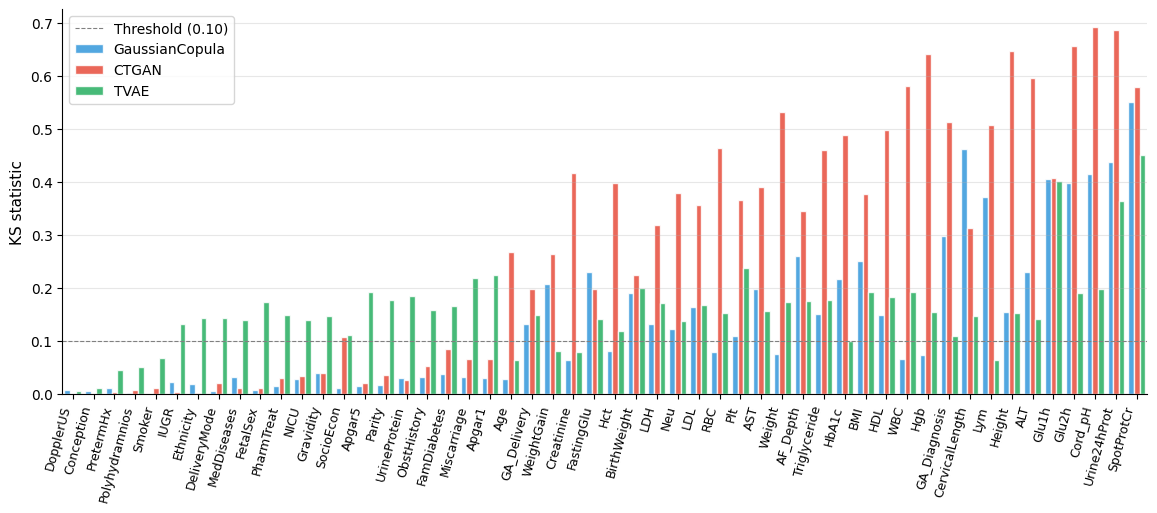

In [ ]:
fig, ax_ks = plt.subplots(figsize=(14, 5))

ks_data = [{"Generator": n, "Variable": v, "KS": s["KS_stat"]}
           for n in GEN_ORDER for v, s in fidelity_results[n]["ks_stats"].items()]
ks_df = pd.DataFrame(ks_data)

vars_sorted = ks_df.groupby("Variable")["KS"].mean().sort_values().index.tolist()
ks_pivot = ks_df.pivot(index="Variable", columns="Generator", values="KS").loc[vars_sorted]

x, w = np.arange(len(vars_sorted)), 0.27

for i, name in enumerate(GEN_ORDER):
    ax_ks.bar(x + (i - 1)*w, ks_pivot[name].values, w,
              label=name, color=GEN_COLORS[name], alpha=0.85, edgecolor="white")

ax_ks.set_xticks(x)
ax_ks.set_xticklabels(vars_sorted, rotation=75, ha="right", fontsize=9)
ax_ks.set_ylabel("KS statistic")

# 🔴 artık bu grafik yeni figürün A paneli
#ax_ks.set_title("A. Column-wise KS statistic", fontweight="bold", loc="left")

ax_ks.axhline(0.1, color="grey", linestyle="--", linewidth=0.8,
              label="Threshold (0.10)")
ax_ks.legend(loc="upper left")
ax_ks.grid(axis="y", alpha=0.3)
ax_ks.margins(x=0)
ax_ks.set_xlim(-0.5, len(x) - 0.5)

plt.savefig(FIG_DIR / "Figure3_KS.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure3_KS.pdf", bbox_inches="tight")
plt.show()

### Figure 3 — Marginal distributions of key clinical variables

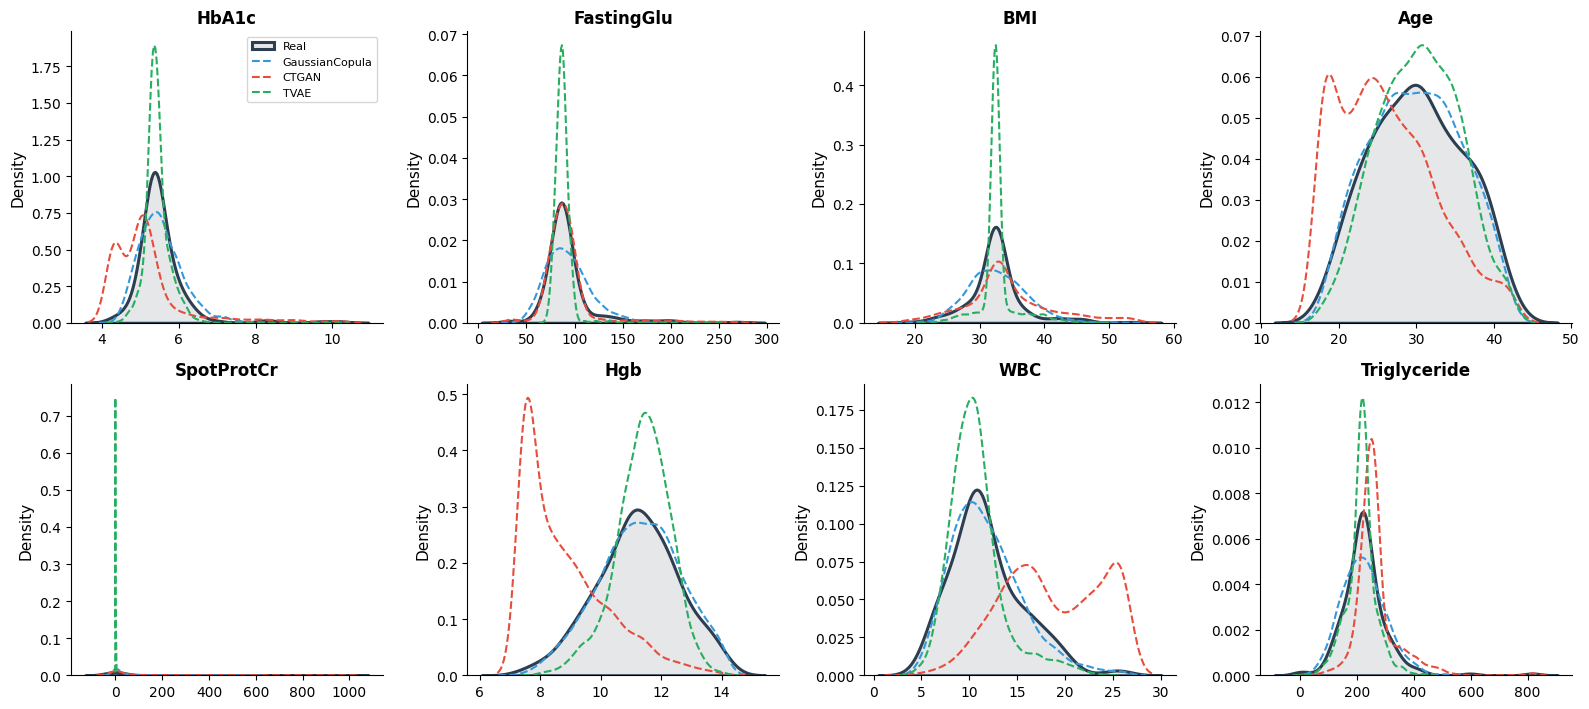

In [ ]:
KEY_VARS = ["HbA1c", "FastingGlu", "BMI", "Age", "SpotProtCr",
            "Hgb", "WBC", "Triglyceride"]
avail = [v for v in KEY_VARS if v in real_train.columns][:8]
n = len(avail); rows = (n + 3) // 4

fig, axes = plt.subplots(rows, 4, figsize=(16, 3.6 * rows))
axes = np.array(axes).flatten()

for i, var in enumerate(avail):
    ax = axes[i]
    sns.kdeplot(real_train[var].dropna(), ax=ax, color=GEN_COLORS["Real"],
                linewidth=2.2, label="Real", fill=True, alpha=0.12)
    for name in GEN_ORDER:
        sns.kdeplot(synthetics[name][var].dropna(), ax=ax,
                    color=GEN_COLORS[name], linewidth=1.5,
                    label=name, linestyle="--")
    ax.set_title(var, fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("Density")
    if i == 0: ax.legend(loc="best", fontsize=8)
    else:      ax.legend().remove()

for j in range(n, len(axes)): axes[j].axis("off")

#fig.suptitle("Figure 3. Marginal distributions of key clinical variables: real vs synthetic",
 #            fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure3_marginals.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure3_marginals.pdf", bbox_inches="tight")
plt.show()


### Figure 4 — Utility (TRTR / TSTR / TRTS)

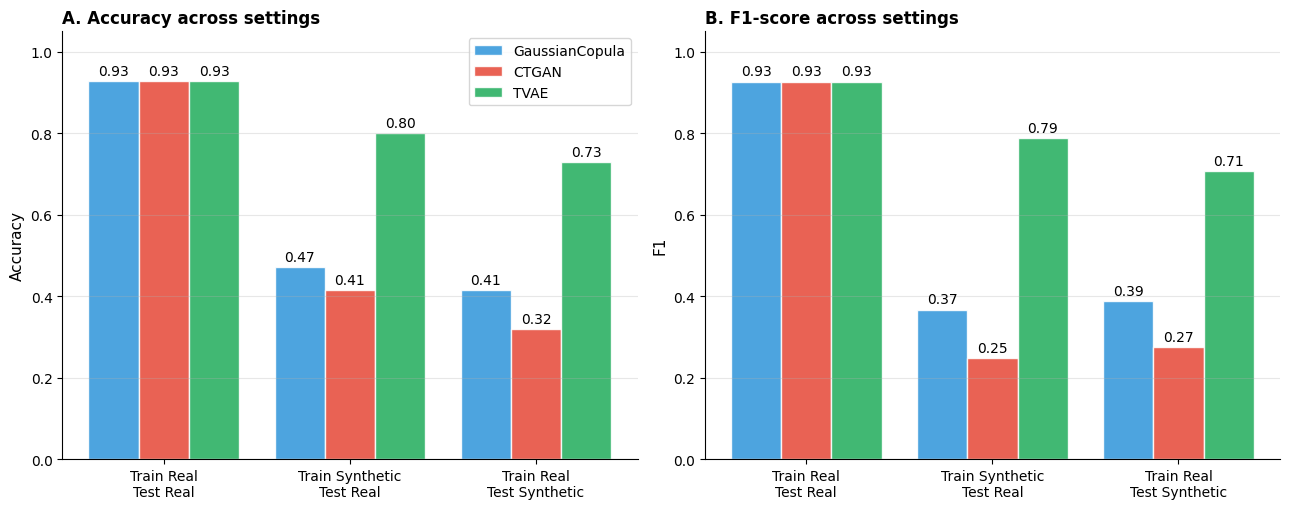

In [18]:
settings = ["TRTR", "TSTR", "TRTS"]
labels = {"TRTR": "Train Real\nTest Real",
          "TSTR": "Train Synthetic\nTest Real",
          "TRTS": "Train Real\nTest Synthetic"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for idx, metric in enumerate(["accuracy", "f1"]):
    ax = axes[idx]; x, w = np.arange(len(settings)), 0.27
    for i, name in enumerate(GEN_ORDER):
        vals = [utility_results[name][s][metric] for s in settings]
        bars = ax.bar(x + (i - 1)*w, vals, w, color=GEN_COLORS[name],
                      label=name, alpha=0.88, edgecolor="white", linewidth=1)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                    f"{v:.2f}", ha="center", fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels([labels[s] for s in settings])
    ax.set_ylabel(metric.upper() if metric == "f1" else metric.capitalize())
    ax.set_title(f"{'A' if idx == 0 else 'B'}. "
                 f"{'Accuracy' if metric == 'accuracy' else 'F1-score'} across settings",
                 fontweight="bold", loc="left")
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
    if idx == 0: ax.legend(loc="upper right")

#fig.suptitle("Figure 4. Utility — ExtraTreesClassifier across TRTR / TSTR / TRTS\n"
 #            ",
  #           fontsize=12, fontweight="bold", y=1.02) #★ TSTR is the key metric: training on synthetic, testing on real"
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure4_utility.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure4_utility.pdf", bbox_inches="tight")
plt.show()


### Figure 5 — Privacy (DCR + MIA)

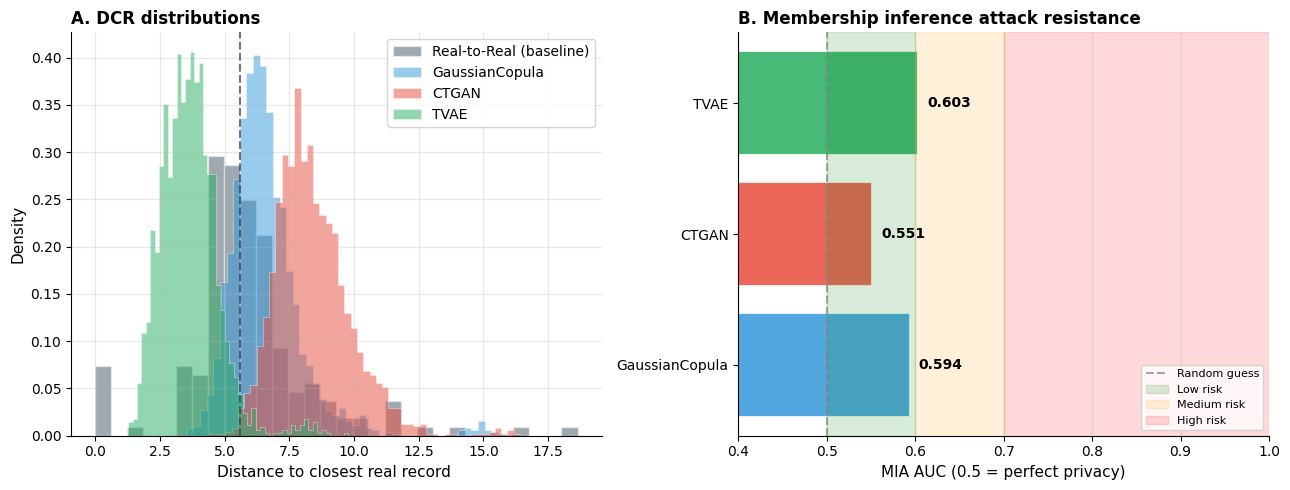

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax0, ax1 = axes

real_dcr = privacy_results[GEN_ORDER[0]]["dcr_real"]
ax0.hist(real_dcr, bins=30, density=True, alpha=0.45,
         color=GEN_COLORS["Real"], label="Real-to-Real (baseline)", edgecolor="white")
for name in GEN_ORDER:
    ax0.hist(privacy_results[name]["dcr_synth"], bins=50, density=True,
             alpha=0.5, color=GEN_COLORS[name], label=name,
             histtype="stepfilled", edgecolor="white", linewidth=0.5)
ax0.axvline(np.median(real_dcr), color=GEN_COLORS["Real"], linestyle="--", alpha=0.7)
ax0.set_xlabel("Distance to closest real record ")
ax0.set_ylabel("Density")
ax0.set_title("A. DCR distributions ",
              fontweight="bold", loc="left")#— higher = better privacy
ax0.legend(); ax0.grid(alpha=0.3)

names = list(GEN_ORDER); aucs = [mia_results[n]["MIA_AUC"] for n in names]
colors = [GEN_COLORS[n] for n in names]
bars = ax1.barh(names, aucs, color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)
ax1.axvline(0.5, color="grey", linestyle="--", alpha=0.7, label="Random guess")
ax1.axvspan(0.5, 0.6, alpha=0.15, color="green",  label="Low risk")
ax1.axvspan(0.6, 0.7, alpha=0.15, color="orange", label="Medium risk")
ax1.axvspan(0.7, 1.0, alpha=0.15, color="red",    label="High risk")
for b, v in zip(bars, aucs):
    ax1.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.3f}",
             va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(0.4, 1.0); ax1.set_xlabel("MIA AUC (0.5 = perfect privacy)")
ax1.set_title("B. Membership inference attack resistance", fontweight="bold", loc="left")
ax1.legend(loc="lower right", fontsize=8); ax1.grid(axis="x", alpha=0.3)


#fig.suptitle("Figure 5. Privacy evaluation — DCR + MIA",
 #            fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure5_privacy.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure5_privacy.pdf", bbox_inches="tight")
plt.show()


### Figure 6 — PCA overlay (real manifold vs synthetic clouds)

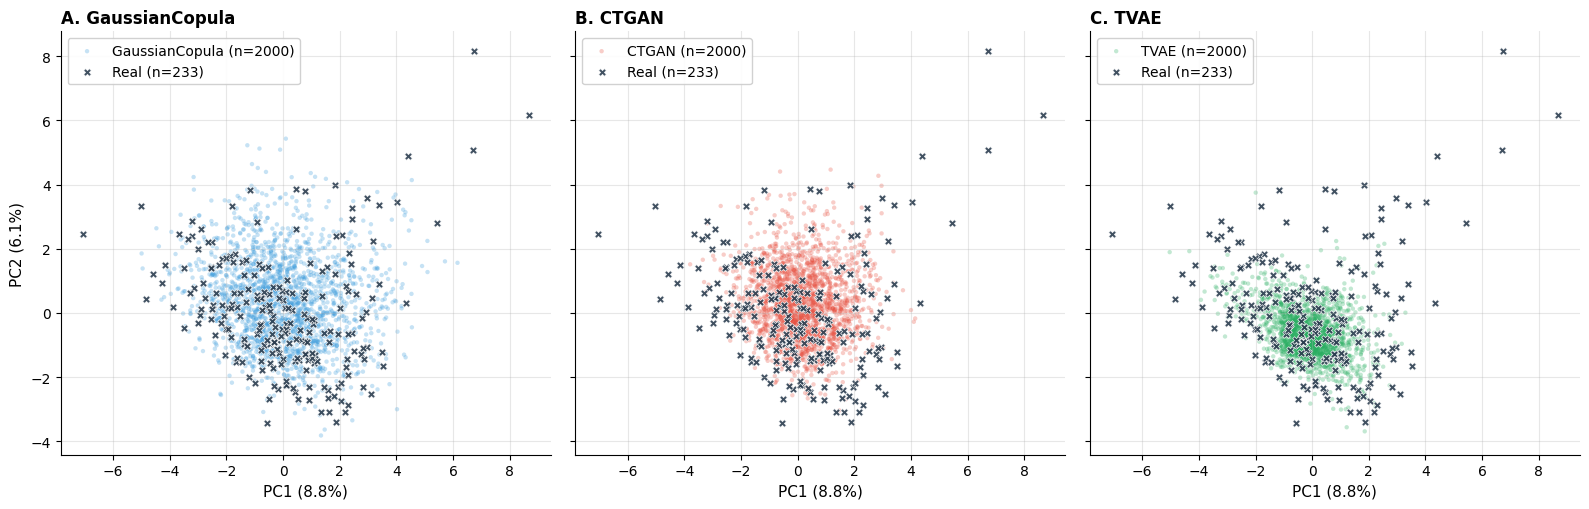

In [ ]:
scaler = StandardScaler()
R = scaler.fit_transform(real_df[num_cols].fillna(0))
pca = PCA(n_components=2)
R_pca = pca.fit_transform(R)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
for i, name in enumerate(GEN_ORDER):
    ax = axes[i]
    S = scaler.transform(synthetics[name][num_cols].fillna(0))
    S_pca = pca.transform(S)
    ax.scatter(S_pca[:, 0], S_pca[:, 1], alpha=0.28, s=10,
               color=GEN_COLORS[name], label=f"{name} (n={len(S_pca)})",
               edgecolors="none")
    ax.scatter(R_pca[:, 0], R_pca[:, 1], alpha=0.9, s=30,
               color=GEN_COLORS["Real"], label=f"Real (n={len(R_pca)})",
               marker="X", edgecolors="white", linewidths=0.5)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    if i == 0: ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{'ABC'[i]}. {name}", fontweight="bold", loc="left")
    ax.legend(loc="best", framealpha=0.9); ax.grid(alpha=0.3)

#fig.suptitle("Figure 6. PCA projection — synthetic manifold overlap with real data",
 #            fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure6_pca.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure6_pca.pdf", bbox_inches="tight")
plt.show()


### Figure 7 — SHAP feature importance preservation

Trains an ExtraTreesClassifier on real data, then on the best (lowest-KS) synthetic dataset, and compares mean absolute SHAP values.


Best generator by fidelity (used for SHAP): GaussianCopula
Computing SHAP for real...
Computing SHAP for synthetic (GaussianCopula)...


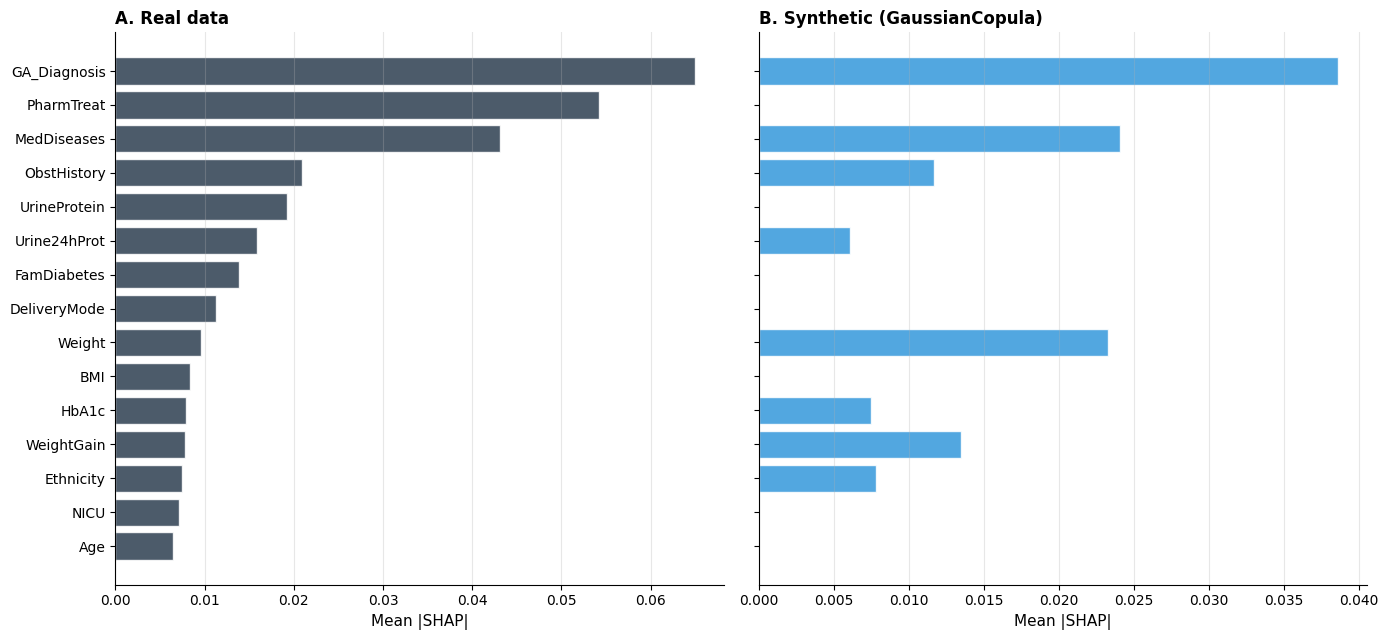

In [ ]:
best_syn = min(GEN_ORDER, key=lambda n: fidelity_results[n]["mean_KS"])
print(f"Best generator by fidelity (used for SHAP): {best_syn}")

feat_cols = [c for c in real_df.columns if c != TARGET_COL]

def shap_importances(df, top_k=15):
    X = df[feat_cols].fillna(df[feat_cols].median())
    y = df[TARGET_COL]
    m = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X, y)
    explainer = shap.TreeExplainer(m)
    n_sample = min(200, len(X))
    sv = explainer.shap_values(X.sample(n_sample, random_state=RANDOM_STATE))
    if isinstance(sv, list):
        mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    else:
        mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.ndim == 3 else np.abs(sv).mean(axis=0)
    return pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False).head(top_k)

print("Computing SHAP for real..."); imp_real = shap_importances(real_df)
print(f"Computing SHAP for synthetic ({best_syn})..."); imp_syn = shap_importances(synthetics[best_syn])

all_feats = list(dict.fromkeys(list(imp_real.index) + list(imp_syn.index)))[:15]
imp_real_a = imp_real.reindex(all_feats, fill_value=0)
imp_syn_a  = imp_syn.reindex(all_feats, fill_value=0)
common = list(set(imp_real.index) & set(imp_syn.index))
rho = spearmanr(imp_real[common], imp_syn[common])[0] if len(common) >= 3 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)
y_pos = np.arange(len(all_feats))
axes[0].barh(y_pos, imp_real_a.values, color=GEN_COLORS["Real"], alpha=0.85, edgecolor="white")
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(all_feats); axes[0].invert_yaxis()
axes[0].set_xlabel("Mean |SHAP|"); axes[0].set_title("A. Real data", fontweight="bold", loc="left")
axes[0].grid(axis="x", alpha=0.3)
axes[1].barh(y_pos, imp_syn_a.values, color=GEN_COLORS[best_syn], alpha=0.85, edgecolor="white")
axes[1].set_xlabel("Mean |SHAP|"); axes[1].set_title(f"B. Synthetic ({best_syn})", fontweight="bold", loc="left")
axes[1].grid(axis="x", alpha=0.3)
#fig.suptitle(f"Figure 7. SHAP feature importance preservation — Spearman ρ = {rho:.2f}",
 #            fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure7_shap.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure7_shap.pdf", bbox_inches="tight")
plt.show()


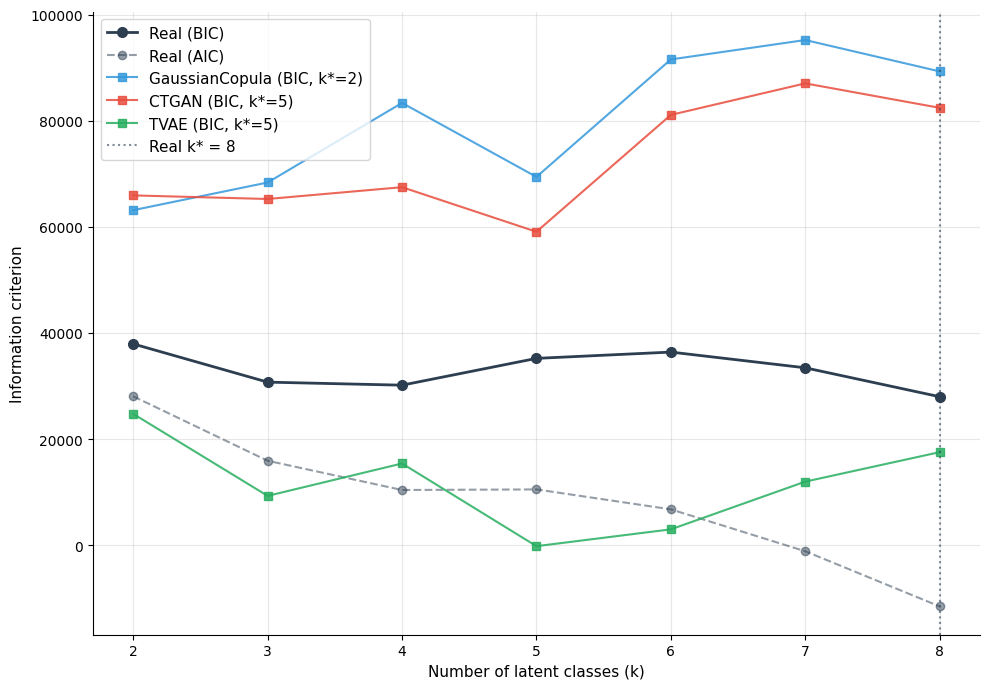

In [26]:
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(1, 1)

ax_a = fig.add_subplot(gs[0, 0])

ax_a.plot(lca_real["ks"], lca_real["bic"], "o-", color=GEN_COLORS["Real"],
          label="Real (BIC)", linewidth=2, markersize=7)
ax_a.plot(lca_real["ks"], lca_real["aic"], "o--", color=GEN_COLORS["Real"],
          alpha=0.5, label="Real (AIC)")

for name in GEN_ORDER:
    ax_a.plot(lca_synth[name]["ks"], lca_synth[name]["bic"], "s-",
              color=GEN_COLORS[name], alpha=0.85,
              label=f"{name} (BIC, k*={lca_synth[name]['best_k']})")

ax_a.axvline(lca_real["best_k"], color=GEN_COLORS["Real"], linestyle=":", alpha=0.6,
             label=f"Real k* = {lca_real['best_k']}")

ax_a.set_xlabel("Number of latent classes (k)")
ax_a.set_ylabel("Information criterion")
#ax_a.set_title("A. Model selection (BIC/AIC) — real vs synthetic",
 #              fontweight="bold", loc="left", pad=12)
ax_a.legend(
    loc="upper center",
    bbox_to_anchor=(0.9, -0.15),
    ncol=3
)
ax_a.legend(loc="best", fontsize=11)

ax_a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure8_phenotype.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure8_phenotype.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

Radar features: ['Age', 'BMI', 'HbA1c', 'FastingGlu', 'SpotProtCr', 'Hgb', 'WBC', 'Triglyceride']


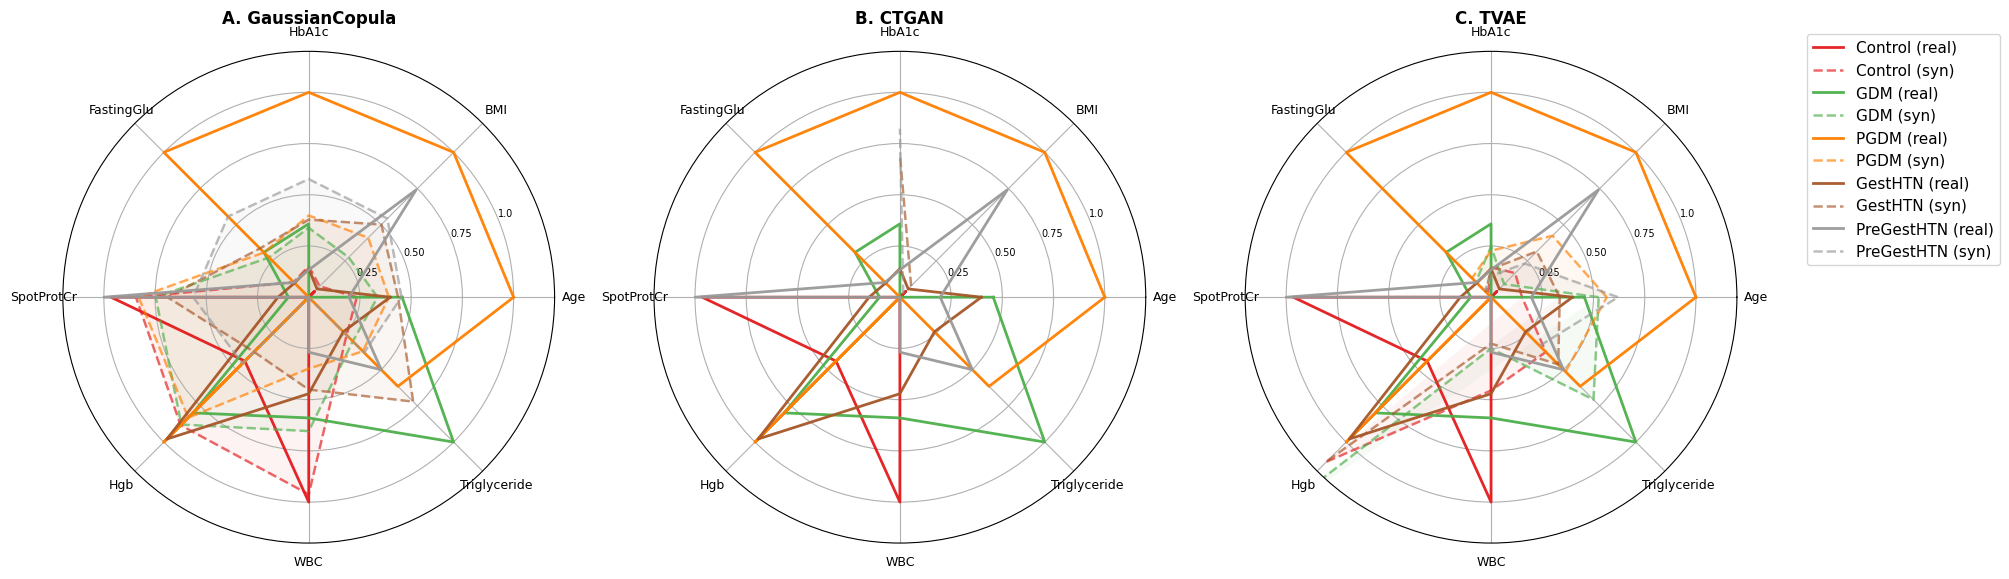


=== Phenotype profile cosine similarity (real vs synthetic) ===
     Generator      Group  Cosine_Sim Note
GaussianCopula    Control       0.926     
GaussianCopula        GDM       0.785     
GaussianCopula       PGDM       0.744     
GaussianCopula    GestHTN       0.666     
GaussianCopula PreGestHTN       0.736     
         CTGAN    Control      -0.335     
         CTGAN        GDM      -0.484     
         CTGAN       PGDM      -0.382     
         CTGAN    GestHTN      -0.796     
         CTGAN PreGestHTN       0.132     
          TVAE    Control       0.463     
          TVAE        GDM       0.861     
          TVAE       PGDM       0.769     
          TVAE    GestHTN       0.924     
          TVAE PreGestHTN       0.229     

=== Mean cosine similarity per generator ===
Generator
CTGAN            -0.373
GaussianCopula    0.771
TVAE              0.649
Name: Cosine_Sim, dtype: float64


In [31]:
# ============================================================================
# RADAR OVERLAY — Real vs Synthetic for all 3 generators
# Requires: real_df, synthetics, TARGET_COL, GROUP_LABELS, FIG_DIR, GEN_ORDER
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm as vec_norm

# Pick clinically meaningful features for radar axes
radar_feats = ["Age", "BMI", "HbA1c", "FastingGlu", "SpotProtCr",
               "Hgb", "WBC", "Triglyceride"]
radar_feats = [f for f in radar_feats if f in real_df.columns][:8]
print(f"Radar features: {radar_feats}")

# Compute group-mean profiles in original units
def group_means(df, feats, group_col=TARGET_COL):
    return df.groupby(group_col)[feats].mean()

real_means = group_means(real_df, radar_feats)
synth_means = {name: group_means(synthetics[name], radar_feats) for name in GEN_ORDER}

# SHARED min-max normalization (from real data) — so overlays are comparable
mins = real_means.min()
maxs = real_means.max()
def norm(df):
    return (df - mins) / (maxs - mins + 1e-9)

real_norm = norm(real_means)
synth_norm = {name: norm(synth_means[name]) for name in GEN_ORDER}

# Angles for the radar axes
angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
angles += [angles[0]]
group_colors = plt.cm.Set1(np.linspace(0, 1, 5))

# Plot — 3 polar subplots side-by-side
fig = plt.figure(figsize=(20, 8))
for i, name in enumerate(GEN_ORDER):
    ax = fig.add_subplot(1, 3, i+1, projection="polar")

    for j, g in enumerate(sorted(real_norm.index)):
        # REAL — solid line
        v_real = real_norm.loc[g, radar_feats].tolist()
        v_real += [v_real[0]]
        ax.plot(angles, v_real, "-", linewidth=2.0,
                color=group_colors[j], alpha=0.95,
                label=f"{GROUP_LABELS.get(int(g), f'G{int(g)}')} (real)")

        # SYNTHETIC — dashed
        if g in synth_norm[name].index:
            v_syn = synth_norm[name].loc[g, radar_feats].tolist()
            v_syn += [v_syn[0]]
            ax.plot(angles, v_syn, "--", linewidth=1.8,
                    color=group_colors[j], alpha=0.65,
                    label=f"{GROUP_LABELS.get(int(g), f'G{int(g)}')} (syn)")
            ax.fill(angles, v_syn, alpha=0.05, color=group_colors[j])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_feats, fontsize=9)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7)
    ax.set_title(f"{'ABC'[i]}. {name}",
                 fontweight="bold", pad=20)

    if i == 2:  # legend only on the rightmost panel
        ax.legend(loc="upper right", bbox_to_anchor=(1.55, 1.05), fontsize=11)

#fig.suptitle("Phenotype preservation — radar overlay of real vs synthetic group profiles",
 #            fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "Figure_radar_overlay_3gen.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure_radar_overlay_3gen.pdf", bbox_inches="tight")
plt.show()


# ============================================================================
# Quantitative companion: cosine similarity (real vs synthetic) per group
# ============================================================================
def cosine_sim(v1, v2):
    return float(np.dot(v1, v2) / (vec_norm(v1) * vec_norm(v2) + 1e-9))

import pandas as pd
similarity_rows = []
for name in GEN_ORDER:
    for g in sorted(real_norm.index):
        if g not in synth_norm[name].index:
            similarity_rows.append({
                "Generator": name,
                "Group": GROUP_LABELS.get(int(g), f"G{int(g)}"),
                "Cosine_Sim": np.nan, "Note": "missing in synth"
            })
            continue
        v_real = real_norm.loc[g, radar_feats].values
        v_syn  = synth_norm[name].loc[g, radar_feats].values
        similarity_rows.append({
            "Generator":  name,
            "Group":      GROUP_LABELS.get(int(g), f"G{int(g)}"),
            "Cosine_Sim": round(cosine_sim(v_real, v_syn), 3),
            "Note":       "",
        })
sim_df = pd.DataFrame(similarity_rows)
print("\n=== Phenotype profile cosine similarity (real vs synthetic) ===")
print(sim_df.to_string(index=False))
print("\n=== Mean cosine similarity per generator ===")
print(sim_df.groupby("Generator")["Cosine_Sim"].mean().round(3))

### Figure 8 — Phenotype preservation (BIC/AIC + radar plot)

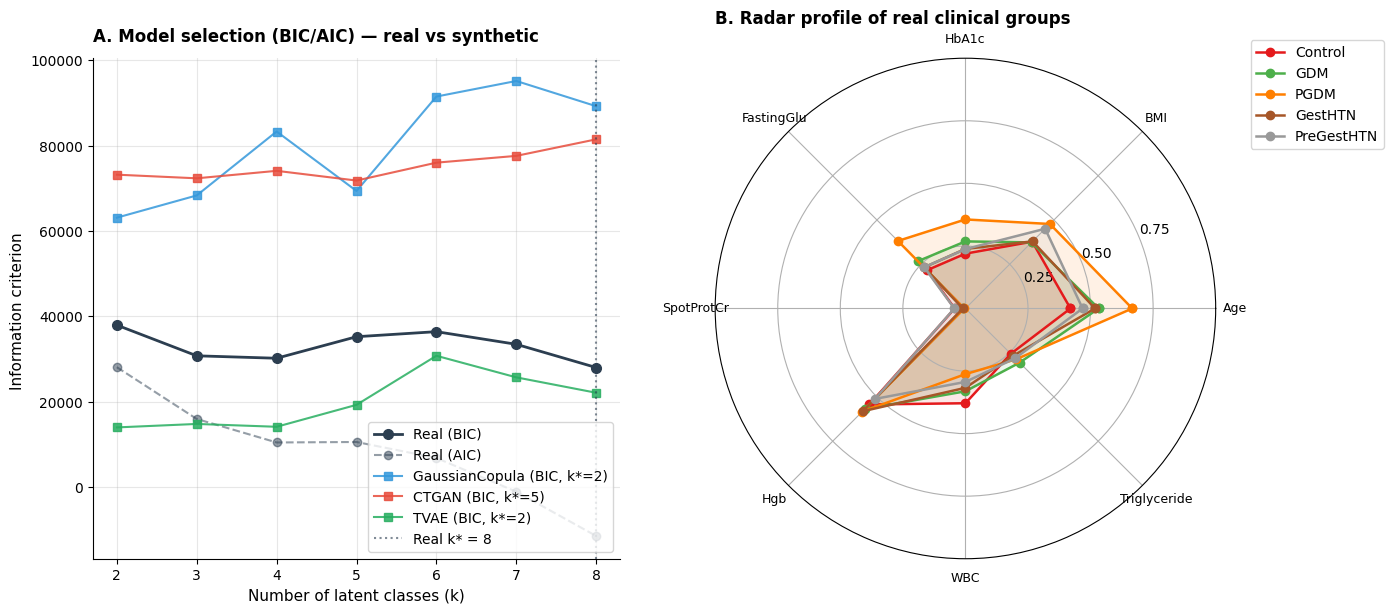

In [ ]:
fig = plt.figure(figsize=(15, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.1)

ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(lca_real["ks"], lca_real["bic"], "o-", color=GEN_COLORS["Real"],
          label="Real (BIC)", linewidth=2, markersize=7)
ax_a.plot(lca_real["ks"], lca_real["aic"], "o--", color=GEN_COLORS["Real"],
          alpha=0.5, label="Real (AIC)")
for name in GEN_ORDER:
    ax_a.plot(lca_synth[name]["ks"], lca_synth[name]["bic"], "s-",
              color=GEN_COLORS[name], alpha=0.85,
              label=f"{name} (BIC, k*={lca_synth[name]['best_k']})")
ax_a.axvline(lca_real["best_k"], color=GEN_COLORS["Real"], linestyle=":", alpha=0.6,
             label=f"Real k* = {lca_real['best_k']}")
ax_a.set_xlabel("Number of latent classes (k)")
ax_a.set_ylabel("Information criterion ")# (lower = better)
ax_a.set_title("A. Model selection (BIC/AIC) — real vs synthetic", fontweight="bold", loc="left",pad=12)
ax_a.legend(loc="best", fontsize=10); ax_a.grid(alpha=0.3)

ax_b = fig.add_subplot(gs[0, 1], projection="polar")
radar_feats = ["Age", "BMI", "HbA1c", "FastingGlu", "SpotProtCr",
               "Hgb", "WBC", "Triglyceride"]
radar_feats = [f for f in radar_feats if f in real_df.columns][:8]

scaler = StandardScaler()
R_std = pd.DataFrame(
    scaler.fit_transform(real_df[radar_feats].fillna(real_df[radar_feats].median())),
    columns=radar_feats
)
R_norm = (R_std - R_std.min()) / (R_std.max() - R_std.min() + 1e-9)
R_norm[TARGET_COL] = real_df[TARGET_COL].values

angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
angles += [angles[0]]
colors_grp = plt.cm.Set1(np.linspace(0, 1, 5))
for i, g in enumerate(sorted(R_norm[TARGET_COL].unique())):
    vals = R_norm[R_norm[TARGET_COL] == g][radar_feats].mean().tolist()
    vals += [vals[0]]
    ax_b.plot(angles, vals, "o-", linewidth=1.8,
              label=GROUP_LABELS.get(int(g), f"G{int(g)}"), color=colors_grp[i])
    ax_b.fill(angles, vals, alpha=0.10, color=colors_grp[i])

ax_b.set_xticks(angles[:-1]); ax_b.set_xticklabels(radar_feats, fontsize=9)
ax_b.set_ylim(0, 1); ax_b.set_yticks([0.25, 0.5, 0.75])
ax_b.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=10)
ax_b.set_title("B. Radar profile of real clinical groups", fontweight="bold", pad=25, loc='left')
ax_b.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05), fontsize=10)

#fig.suptitle("Figure 8. Phenotype preservation — latent class structure & feature radar",
 #            fontsize=13, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "Figure8_phenotype.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "Figure8_phenotype.pdf", bbox_inches="tight")
plt.show()


### Supplementary Figure S1 — Per-variable KS heatmap

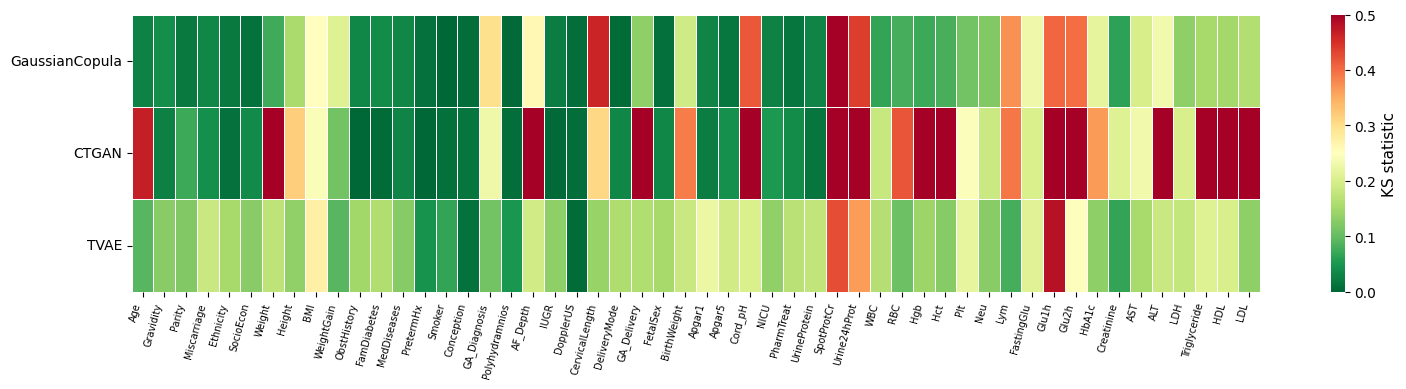

In [ ]:
data = [[fidelity_results[n]["ks_stats"][c]["KS_stat"] for c in num_cols]
        for n in GEN_ORDER]
M = pd.DataFrame(data, index=GEN_ORDER, columns=num_cols)

fig, ax = plt.subplots(figsize=(max(14, len(num_cols)*0.35), 3.6))
sns.heatmap(M, cmap="RdYlGn_r", vmin=0, vmax=0.5, annot=False,
            cbar_kws={"label": "KS statistic"}, ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
#ax.set_title("Figure S1. Per-variable KS statistic heatmap "
  #           "(green = good fidelity, red = poor)",
             #fontweight="bold", loc="left", fontsize=11)
plt.savefig(FIG_DIR / "FigureS1_ks_heatmap.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "FigureS1_ks_heatmap.pdf", bbox_inches="tight")
plt.show()


### Supplementary Figure S2 — TSTR confusion matrices

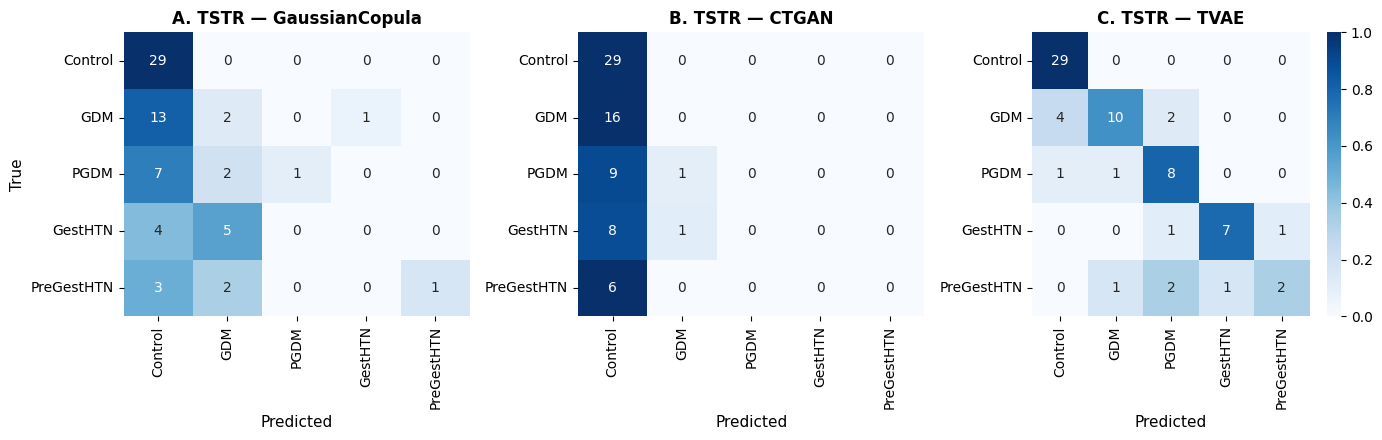

In [29]:
feat_cols = [c for c in real_df.columns if c != TARGET_COL]
X_real, y_real = real_df[feat_cols], real_df[TARGET_COL]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_real, y_real, test_size=0.3, stratify=y_real, random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
labels_sorted = sorted(y_real.unique())
label_names = [GROUP_LABELS.get(int(g), f"G{int(g)}") for g in labels_sorted]

for i, name in enumerate(GEN_ORDER):
    synth = synthetics[name]
    m = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE)
    m.fit(synth[feat_cols], synth[TARGET_COL])
    preds = m.predict(X_te)
    cm = confusion_matrix(y_te, preds, labels=labels_sorted)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=label_names, yticklabels=label_names,
                cbar=(i == 2))
    axes[i].set_title(f"{'ABC'[i]}. TSTR — {name}", fontweight="bold")
    axes[i].set_xlabel("Predicted")
    if i == 0: axes[i].set_ylabel("True")

#fig.suptitle("Figure S2. TSTR confusion matrices per generator",
 #            fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "FigureS2_tstr_confusion.png", dpi=1200, bbox_inches="tight")
plt.savefig(FIG_DIR / "FigureS2_tstr_confusion.pdf", bbox_inches="tight")
plt.show()


---
## Done!

All figures are saved in `./outputs/figures/` as both PNG (1200 dpi) and PDF.

The summary CSV (`./outputs/summary_table.csv`) contains the headline numbers for **Table 1** of the manuscript.

If you want to **re-run with more training epochs** for a final BMC submission:
- Set `EPOCHS_DL = 500` in cell 0
- Re-run cell 4 onwards (skip the imports/loading cells if data is already cached)

For questions or issues, see the README.md.
